In [1]:


import numpy as np
print(f"NumPy version: {np.__version__}")
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

print(f"NumPy version: {np.__version__}")

NumPy version: 1.26.4
NumPy version: 1.26.4


In [2]:
data = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

In [3]:
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [6]:
data.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

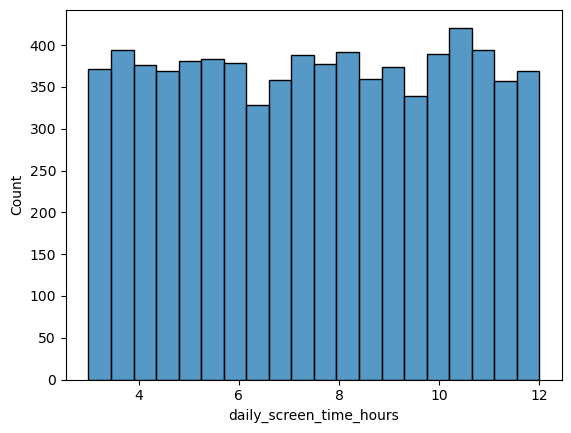

In [7]:
sns.histplot(data['daily_screen_time_hours'])
plt.show()

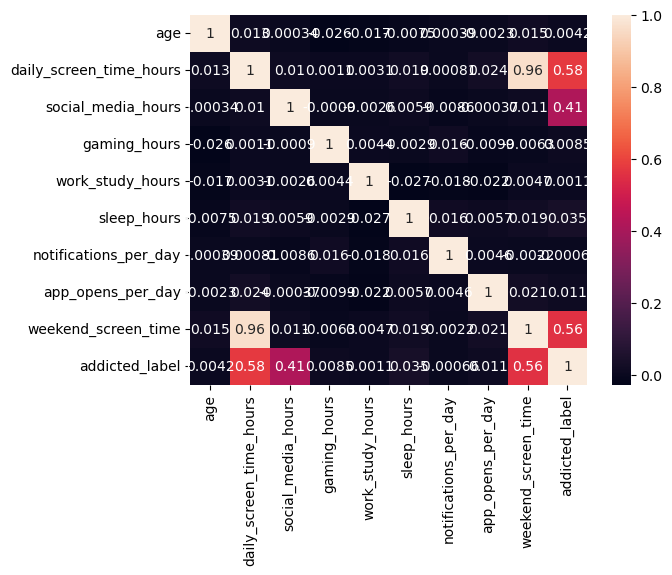

In [8]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

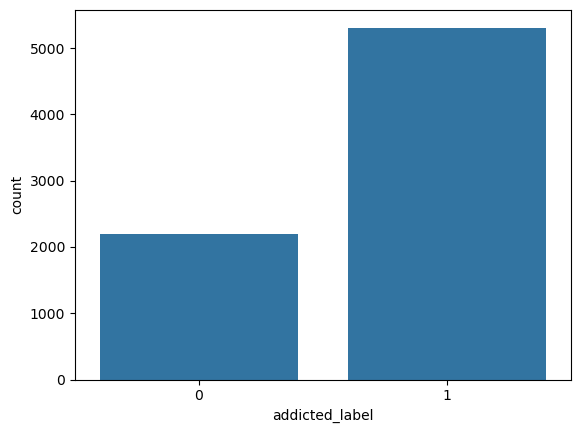

In [9]:
sns.countplot(x='addicted_label', data=data)
plt.show()

In [10]:
#encoding
data['gender'] = data['gender'].astype('category').cat.codes
data['stress_level'] = data['stress_level'].astype('category').cat.codes
data['academic_work_impact'] = data['academic_work_impact'].astype('category').cat.codes

In [11]:
X = data[[
'age',
'gender',
'daily_screen_time_hours',
'social_media_hours',
'gaming_hours',
'work_study_hours',
'sleep_hours',
'notifications_per_day',
'app_opens_per_day',
'weekend_screen_time',
'stress_level',
'academic_work_impact'
]]

y = data['addicted_label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
data.shape
X.shape
y.shape
print(data.shape)
print(X.shape)
print(y.shape)

(7500, 16)
(7500, 12)
(7500,)


In [14]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
predictions = model.predict(X_test)

In [16]:

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9273333333333333


In [17]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       456
           1       0.96      0.94      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



[[411  45]
 [ 64 980]]


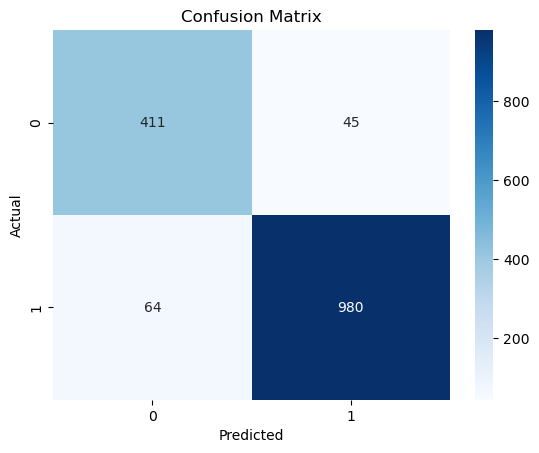

In [18]:
cm = confusion_matrix(y_test, predictions)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

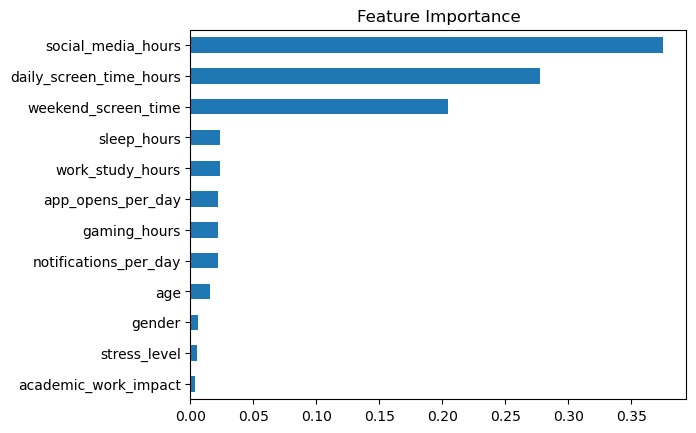

In [19]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [20]:
#SHAP will explain
#WHY the model predicted addicted

In [21]:
import shap

In [37]:
explainer = shap.TreeExplainer(model)
print(X_test.shape)
shap_values = explainer.shap_values(X_test)

(1500, 12)


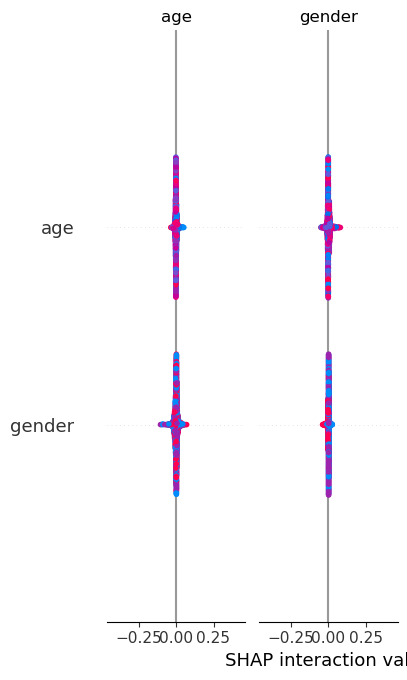

In [23]:
shap.summary_plot(shap_values, X_test)

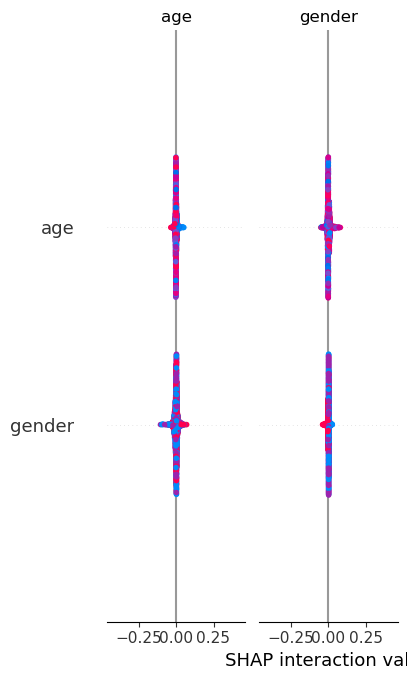

In [24]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [25]:
index = 0

In [38]:
# Initialize JavaScript (required for force_plot)

print(len(X_test.iloc[index]))
print(len(shap_values[1][index]))
print(np.array(shap_values).shape)
shap.initjs()# This gives you all 12 features for that specific row and class
class_1_shap_values = shap_values[index, :, 1] 

shap.force_plot(
    explainer.expected_value[1], 
    class_1_shap_values, 
    X_test.iloc[index]
)

12
2
(1500, 12, 2)


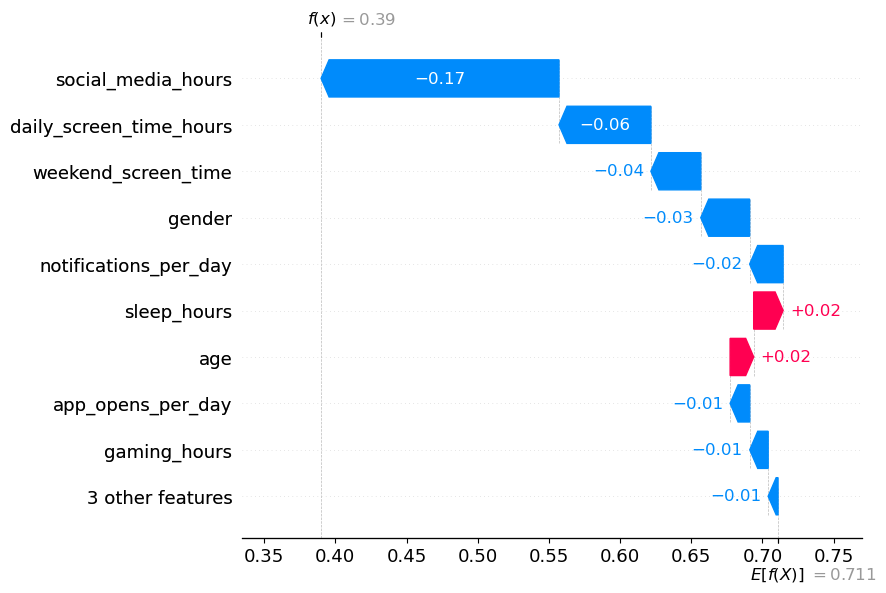

In [39]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    class_1_shap_values,
    feature_names=X.columns
)

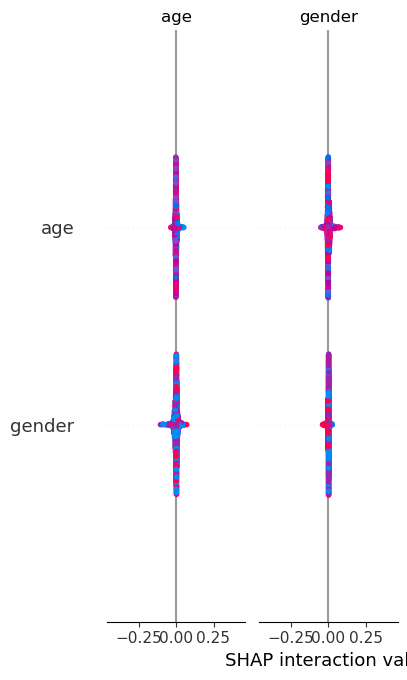

In [43]:
shap.summary_plot(shap_values, X_test)

In [45]:
user = X_test.iloc[index]
shap_vals = shap_values[index, :, 1]

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "value": user.values,
    "impact": shap_vals
})

shap_df = shap_df.sort_values(by="impact", ascending=False)
print(shap_df)

                    feature   value    impact
6               sleep_hours    8.66  0.020655
0                       age   30.00  0.016555
10             stress_level    0.00  0.007410
5          work_study_hours    2.97 -0.005733
11     academic_work_impact    0.00 -0.008614
4              gaming_hours    3.30 -0.012928
8         app_opens_per_day  117.00 -0.013800
7     notifications_per_day   65.00 -0.023492
1                    gender    2.00 -0.034311
9       weekend_screen_time    8.67 -0.035046
2   daily_screen_time_hours    7.45 -0.064546
3        social_media_hours    3.05 -0.167074


In [58]:
recommendations = []

# Sort by absolute impact to see what matters most to the model
top_features = shap_df.sort_values(by="abs_impact", ascending=False)

for _, row in top_features.iterrows():
    feature = row["feature"]
    value = row["value"]
    impact = row["impact"]

    # ONLY give a recommendation if the impact is POSITIVE (increasing addiction risk)
    if impact > 0: 
        if feature == "social_media_hours" and value > 3:
            recommendations.append(f"Reduce social media usage (currently {value} hrs/day)")

        elif feature == "daily_screen_time_hours" and value > 6:
            recommendations.append(f"Limit screen time (currently {value} hrs/day)")

        elif feature == "sleep_hours" and value < 7:
            recommendations.append(f"Increase sleep duration (currently {value} hrs)")

        elif feature == "app_opens_per_day" and value > 100:
            recommendations.append(f"Try reducing frequent app checking ({value} opens/day)")

# Show the top 3 relevant fixes
print(recommendations[:3])


[]


In [ ]:
print("Addiction Risk Score:", model.predict_proba(user.to_frame().T))

print("\nTop Factors:")
print(shap_df.head(3))

if not recommendations:
    print("Keep it up! Your current habits are not showing significant addiction risks.")
else:
    print("Recommendations:")
    for r in recommendations:
        print("•", r)

Addiction Risk Score: [[0.61 0.39]]

Top Factors:
         feature  value    impact  abs_impact
6    sleep_hours   8.66  0.020655    0.020655
0            age  30.00  0.016555    0.016555
10  stress_level   0.00  0.007410    0.007410

Recommendations:
• Reduce social media usage (currently 3.05 hrs/day)
• Limit screen time (currently 7.45 hrs/day)
• Try reducing frequent app checking (117.0 opens/day)


In [57]:
risk_score = model.predict_proba(user.to_frame().T)[0][1]

if risk_score > 0.7:
    level = "High"
elif risk_score > 0.4:
    level = "Moderate"
else:
    level = "Low"

print(f"Addiction Risk Level: {level} ({risk_score:.2f})")

Addiction Risk Level: Low (0.39)
